# 🧠 Introducción a la Computación Cuántica





La computación cuántica permite resolver un conjunto de problemas altamente costosos para la computación clásica de una forma más rápida y eficiente.

Un ejemplo de este tipo de problemas es la **búsqueda en un conjunto no estructurado**, donde la computación cuántica ofrece un algoritmo con complejidad media:

- Cuántico: **O(sqrt(n))**
- Clásico: **O(n)**

Las características de la mecánica cuántica que aportan esta ventaja son:

- Superposición  
- Entrelazamiento  
- Interferencia  

En este notebook se mostrarán ejemplos de circuitos que hacen uso de estas propiedades.

---

# 🔀 Superposición

La **superposición** permite operar con varios estados al mismo tiempo.

Esta característica se basa en la indeterminación del estado de una propiedad binaria en un sistema cuántico.

## Ejemplo físico

Un ejemplo de esta propiedad es el **spin de un electrón**, que puede apuntar:

- Arriba  
- Abajo  

Una superposición de este estado es una combinación de ambos valores posibles.

## Qubits

Un **qubit** codifica dos estados:

- 0  
- 1  

Un qubit en superposición será una combinación de ambos estados.

## Ventaja espacial

Mediante **n qubits** podemos representar:

$$
2^n \text{ estados}
$$

Esto proporciona una ventaja exponencial en representación de información.

# ⚙️ Circuito Cuántico de Ejemplo

En este ejemplo:

- Se crean 2 qubits  
- Se ponen en superposición usando puertas Hadamard (H)  
- Se miden los resultados  

## Simulación

Se utiliza un simulador ideal para ejecutar el circuito:

- Se lanzan **1024 ejecuciones (shots)**  
- Se obtiene la distribución de resultados  

## Visualización

Finalmente, se representa un histograma con la distribución de probabilidades de los estados medidos.

     ┌───┐┌─┐   
q_0: ┤ H ├┤M├───
     ├───┤└╥┘┌─┐
q_1: ┤ H ├─╫─┤M├
     └───┘ ║ └╥┘
c: 2/══════╩══╩═
           0  1 
Resultados {'01': 284, '10': 260, '00': 231, '11': 249}


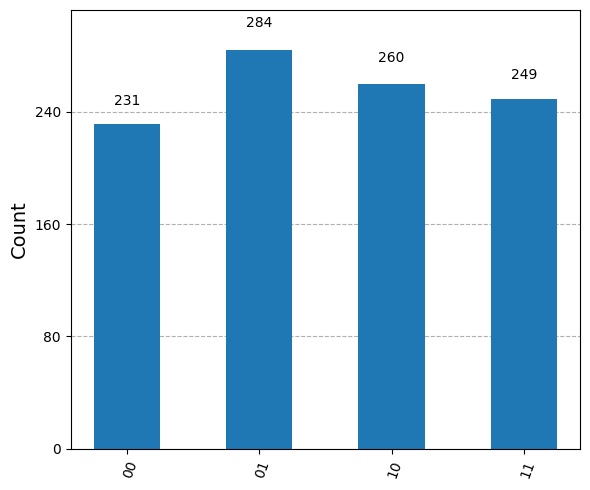

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit

qc = QuantumCircuit(2,2)

#Ponemos ambos qubits en superposición y medimos los resultados
qc.h(0)
qc.h(1)

qc.measure([0,1],[0,1])

print(qc.draw(output='text'))

#Importamos el simulador que nos va a permitir ejecutar el circuito en condiciones ideales
from qiskit.primitives import StatevectorSampler

#Instanciamos el simulador
sampler = StatevectorSampler()

#Ejecutamos el circuito con un número de shots específicos
job = sampler.run([qc], shots=1024)

#Obtenemos los resultados y los mostramos
result = job.result()[0]
counts = result.data.c.get_counts()
print(f"Resultados {counts}")

#Mostramos la distribución gráfica de los resultados
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

plot_histogram(counts, figsize=(6,5))
plt.show()

# 🔗 Entrelazamiento

En el caso anterior, un qubit es independiente de otro; es decir, si medimos uno, esto no afecta a la probabilidad de salida del otro.

Sin embargo, estos qubits se pueden manipular para que ambos se correlacionen, de forma que la medición de uno afecte al estado probabilístico del otro.

Esto nos permite establecer correlaciones imposibles en la computación clásica.

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
Resultados {'00': 514, '11': 510}


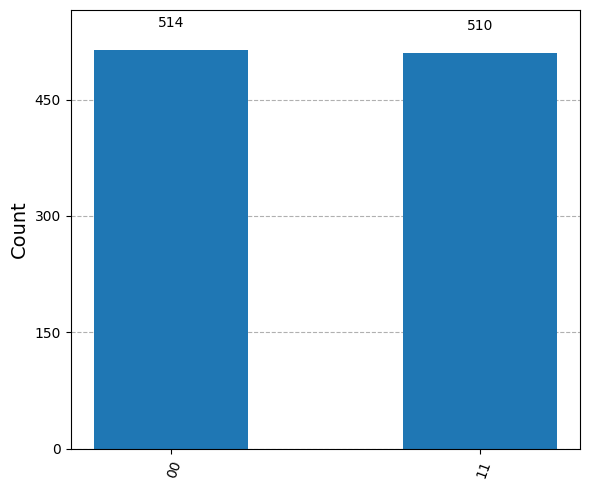

In [ ]:
#################### Entrelazamiento ##################
"""
En el caso anterior un qubit es independiente de otro, es decir que si medimos uno, esto no afecta a la
probabilidad de salida del otro.

Sin embargo, estos qubits se pueden manipular para que ambos se correlacionen, de forma que la medición
de uno afecte al estado probabilístico del otro.

Esto nos permite establecer correlaciones imposibles para la clásica.
"""
qc = QuantumCircuit(2,2)

qc.h(0)
qc.cx(0,1)

qc.measure([0,1],[0,1])

print(qc.draw(output='text'))

#Ejecutamos el circuito mediante el simulador previamente instanciado
job = sampler.run([qc], shots=1024)

#Obtenemos los resultados y los mostramos
result = job.result()[0]
counts = result.data.c.get_counts()
print(f"Resultados {counts}")

#Mostramos la distribución gráfica de los resultados
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

plot_histogram(counts, figsize=(6,5))
plt.show()

#Como podemos observar, ahora los resultados se limitan a dos estados (00 y 11)
#A este estado se le denomina estado de Bell

# 🌊 Interferencia

La probabilidad asociada a un qubit se corresponde con el cuadrado de la amplitud de dicho qubit.

Esta amplitud es el factor que multiplica al vector correspondiente a un estado.

## Tipos de interferencia

Las amplitudes pueden interaccionar entre ellas de dos formas:

- **Interferencia constructiva**: las amplitudes se amplifican debido a su interacción.  
- **Interferencia destructiva**: las amplitudes se cancelan debido a su interacción.  

     ┌───┐┌───┐┌───┐┌─┐
  q: ┤ H ├┤ Z ├┤ H ├┤M├
     └───┘└───┘└───┘└╥┘
c: 1/════════════════╩═
                     0 
Resultados {'1': 1024}


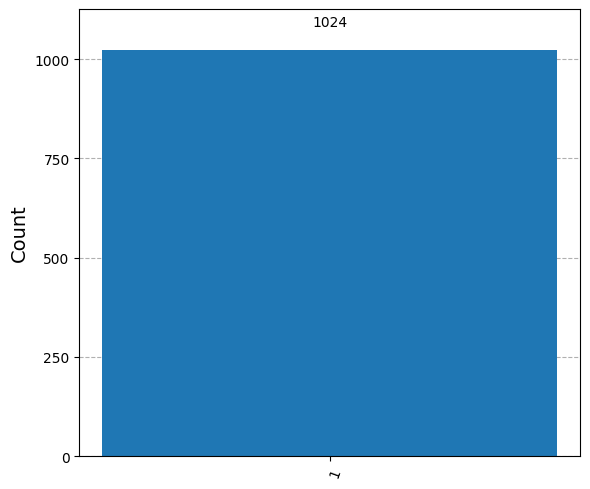

In [ ]:
qc = QuantumCircuit(1,1)

qc.h(0)
qc.z(0) #Se cambia la fase
qc.h(0) #Al volver a hacer haddamard sobre ambos estados obtenemos que un estado cero se cancela con el otro y que el estado |1> ocurre con una probabilidad de 1

qc.measure([0],[0])
print(qc.draw(output='text'))

#Ejecutamos el circuito mediante el simulador previamente instanciado
job = sampler.run([qc], shots=1024)

#Obtenemos los resultados y los mostramos
result = job.result()[0]
counts = result.data.c.get_counts()
print(f"Resultados {counts}")

#Mostramos la distribución gráfica de los resultados
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

plot_histogram(counts, figsize=(6,5))
plt.show()

#El resultado es el estado 1 en todo momento

# 🔍 Algoritmo de Grover

Los diferentes algoritmos cuánticos aprovechan estas características para resolver problemas con un coste polinómico.

Un ejemplo de esto es el **algoritmo de Grover**, que permite realizar una búsqueda sobre un conjunto de datos no estructurado.

Este algoritmo presenta una complejidad:

- Cuántico: **O(√n)**  
- Clásico: **O(n)**  

## 🧩 Pasos del algoritmo

El algoritmo está compuesto por los siguientes pasos:

1. Preparación del estado inicial  
2. Implementación del oráculo  
3. Aplicación del operador de difusión de Grover  
4. Repetir los pasos 2 y 3 aproximadamente:  
   $$
   \frac{\pi}{4}\sqrt{n}
   $$  
5. Medición  

---

# ⚙️ 1. Preparación del estado inicial

Inicializamos el sistema en una **superposición uniforme** de todos los posibles estados.

El objetivo es buscar una cadena específica de números binarios.

Para ello, creamos un sistema de **2ⁿ dimensiones**, representadas mediante **2ⁿ números binarios**.

     ┌───┐┌─┐   
q_0: ┤ H ├┤M├───
     ├───┤└╥┘┌─┐
q_1: ┤ H ├─╫─┤M├
     └───┘ ║ └╥┘
c: 2/══════╩══╩═
           0  1 
Resultados {'10': 224, '01': 252, '11': 282, '00': 266}


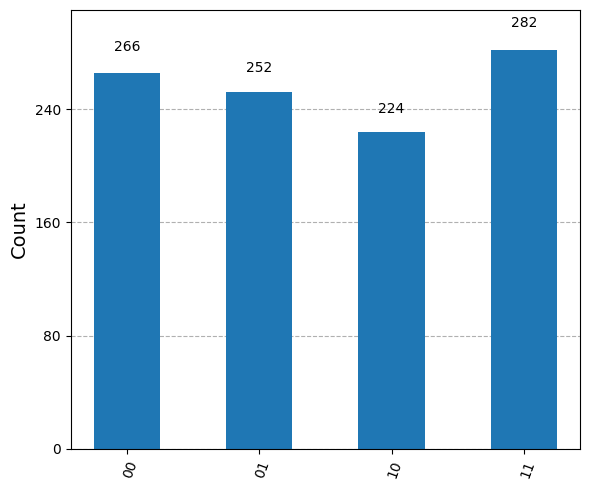

In [ ]:
num_qubits = 2
num_bits = 2
qc = QuantumCircuit(num_qubits, num_bits)

qc.h(range(num_qubits))
qc.measure([0,1],[0,1])

print(qc.draw(output='text'))

#Ejecutamos el circuito mediante el simulador previamente instanciado
job = sampler.run([qc], shots=1024)

#Obtenemos los resultados y los mostramos
result = job.result()[0]
counts = result.data.c.get_counts()
print(f"Resultados {counts}")

#Mostramos la distribución gráfica del estado inicial
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

plot_histogram(counts, figsize=(6,5))
plt.show()

# 🧠 Oráculo en el Algoritmo de Grover

Supongamos que solo buscamos un único *string*. Para ello, definimos una función tal que:

- \( f(x) = 1 \) para la cadena objetivo  
- \( f(x) = 0 \) para el resto  

A esta cadena objetivo la denominamos **w**.

## 📦 Definición de oráculo

Un **oráculo** es una caja negra que implementa la función \( f(x) \). En este contexto, actúa de la siguiente forma:

$$
U_w|x\rangle = -|x\rangle \quad \text{si } x = w \text{ (cuando } f(x)=1)
$$

$$
U_w|x\rangle = |x\rangle \quad \text{si } x \neq w \text{ (cuando } f(x)=0)
$$

## 🎯 Interpretación

El operador unitario \( U_w \):

- Cambia la **fase** del estado solución (multiplicándolo por -1)  
- Mantiene el resto de estados sin modificar  

Esto permite marcar el estado correcto sin destruir la superposición.

Statevector([-0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j],
            dims=(2, 2))


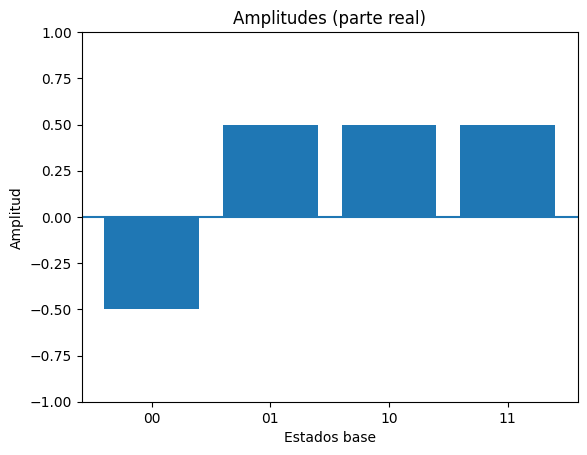

In [ ]:
#Imaginemos que queremos marcar el estado 00
num_qubits = 2
num_bits = 2
qc = QuantumCircuit(num_qubits, num_bits)

qc.h(range(num_qubits))
qc.x(0)
qc.x(1)
qc.cz(0,1)
qc.x(0)
qc.x(1)

from qiskit.quantum_info import Statevector
import numpy as np
# Obtener estado final
state = Statevector.from_instruction(qc)
print(state)

# Etiquetas de estados
labels = ['00', '01', '10', '11']

# Amplitudes (parte real)
amplitudes = np.real(state.data)

# Crear gráfico
plt.figure()
plt.bar(labels, amplitudes)

# Forzar rango de -1 a 1
plt.ylim(-1, 1)

# Línea horizontal en 0 (muy útil visualmente)
plt.axhline(0)

plt.title("Amplitudes (parte real)")
plt.xlabel("Estados base")
plt.ylabel("Amplitud")

plt.show()

Statevector([ 0.5+0.j, -0.5+0.j,  0.5+0.j,  0.5+0.j],
            dims=(2, 2))


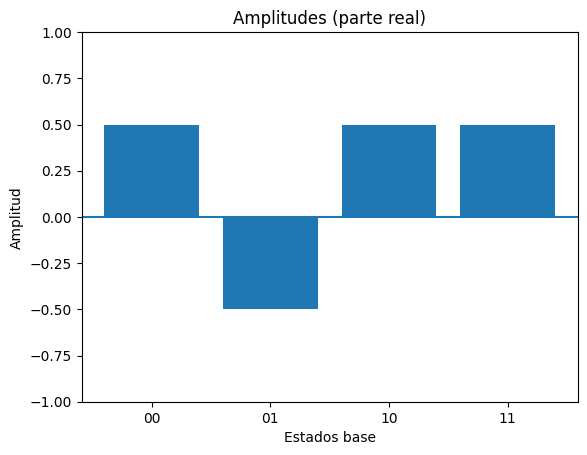

In [ ]:
#Como cambiaríamos la amplitud del estado 01?
num_qubits = 2
num_bits = 2
qc = QuantumCircuit(num_qubits, num_bits)

qc.h(range(num_qubits))
qc.x(0)
qc.x(1)
qc.cz(0,1)
qc.x(1)

# Obtener estado final
state = Statevector.from_instruction(qc)
print(state)

# Etiquetas de estados
labels = ['00', '01', '10', '11']

# Amplitudes (parte real)
amplitudes = np.real(state.data)

# Crear gráfico
plt.figure()
plt.bar(labels, amplitudes)

# Forzar rango de -1 a 1
plt.ylim(-1, 1)

# Línea horizontal en 0 (muy útil visualmente)
plt.axhline(0)

plt.title("Amplitudes (parte real)")
plt.xlabel("Estados base")
plt.ylabel("Amplitud")

plt.show()

# 🔄 Operador de Difusión de Grover

De esta forma hemos marcado el *string* de bits que queremos encontrar; sin embargo, la distribución de probabilidades sigue siendo la misma.

Para resolver este problema, aplicamos el **operador de difusión de Grover**.

## ⚙️ Definición

El operador de difusión de Grover es otra operación unitaria que actúa como una **rotación sobre la superposición uniforme** de los estados.

El ángulo de rotación viene dado por:

$$
2 \cdot \arcsin\left(\frac{1}{\sqrt{n}}\right)
$$

## 🎯 Interpretación

Este operador:

- Refleja las amplitudes respecto a la media  
- Aumenta la probabilidad del estado marcado  
- Disminuye la probabilidad del resto  

De esta forma, se amplifica progresivamente la probabilidad de medir la solución correcta.

     ┌───┐┌───┐   ┌───┐┌───┐               ┌───┐┌───┐     ┌─┐   
q_0: ┤ H ├┤ X ├─■─┤ H ├┤ X ├────────────■──┤ X ├┤ H ├─────┤M├───
     ├───┤├───┤ │ ├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤├───┤┌───┐└╥┘┌─┐
q_1: ┤ H ├┤ X ├─■─┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─╫─┤M├
     └───┘└───┘   └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘ ║ └╥┘
c: 2/══════════════════════════════════════════════════════╩══╩═
                                                           0  1 
Resultados {'01': 1024}


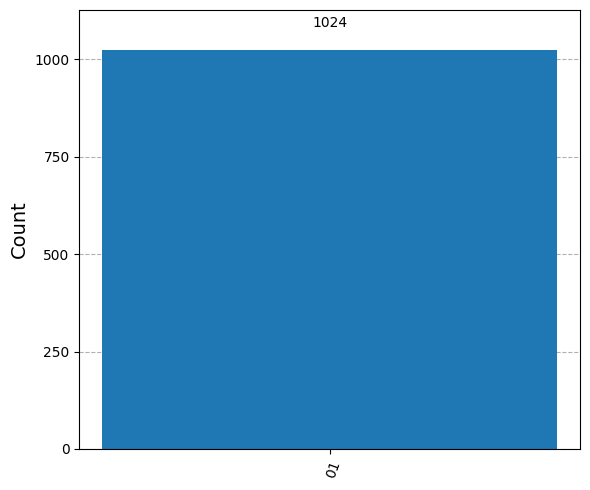

In [ ]:
num_qubits = 2
num_bits = 2
qc = QuantumCircuit(num_qubits, num_bits)

#Inicialización
qc.h(range(num_qubits))

#Cambio de fase del estado 01
qc.x(0)
qc.x(1)
qc.cz(0,1)
qc.x(1)

#Operador de difusión
qc.h(range(num_qubits))
qc.x(range(num_qubits))
qc.h(num_qubits-1)
qc.mcx(list(range(num_qubits-1)), num_qubits-1)
qc.h(num_qubits-1)
qc.x(range(num_qubits))
qc.h(range(num_qubits))

qc.measure([0,1],[0,1])

print(qc.draw(output='text'))

#Ejecutamos el circuito mediante el simulador previamente instanciado
job = sampler.run([qc], shots=1024)

#Obtenemos los resultados y los mostramos
result = job.result()[0]
counts = result.data.c.get_counts()
print(f"Resultados {counts}")

#Mostramos la distribución gráfica del estado inicial
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

plot_histogram(counts, figsize=(6,5))
plt.show()